In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import os

import SEACells

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100

# Load Replogle Datasets
- K562 Essential
- RPE1

In [2]:
# !wget -c -O /ibex/user/chenj0i/Perturbation/data/raw_data/Replogle_K562_essential.h5ad "https://zenodo.org/records/7041849/files/ReplogleWeissman2022_K562_essential.h5ad?download=1"
# !wget -c -O /ibex/user/chenj0i/Perturbation/data/raw_data/Replogle_rpe1.h5ad "https://zenodo.org/records/7041849/files/ReplogleWeissman2022_rpe1.h5ad?download=1"

# Data processing
## Replogle K562 Essential

### Global data processing

In [3]:
# ad = sc.read("/ibex/user/chenj0i/Perturbation/data/raw_data/Replogle_K562_essential.h5ad")

# ad.obs["condition"] = np.where(ad.obs["nperts"].astype(int) == 0, "control", "perturbed")

# # Define perturbation multiplicity
# ad.obs["perturbation_multiplicity"] = "unknown"
# ad.obs.loc[ad.obs["nperts"].astype(int) == 0, "perturbation_multiplicity"] = "control"
# ad.obs.loc[ad.obs["nperts"].astype(int) == 1, "perturbation_multiplicity"] = "single"
# ad.obs.loc[ad.obs["nperts"].astype(int) == 2, "perturbation_multiplicity"] = "dual"
# ad.obs.loc[ad.obs["nperts"].astype(int) > 2, "perturbation_multiplicity"] = "multi"

# # Define analysis group
# ad.obs["analysis_group"] = ad.obs["perturbation_multiplicity"].copy()

# for col in ["condition", "perturbation_multiplicity", "analysis_group"]:
#     ad.obs[col] = ad.obs[col].astype("category")

# print(ad.obs["condition"].value_counts())
# print(ad.obs["perturbation_multiplicity"].value_counts())
# print(ad.obs["analysis_group"].value_counts())

condition
perturbed    299694
control       10691
Name: count, dtype: int64
perturbation_multiplicity
single     299694
control     10691
Name: count, dtype: int64
analysis_group
single     299694
control     10691
Name: count, dtype: int64


In [4]:
# raw_path = "/ibex/user/chenj0i/Perturbation/data/raw_data/Replogle_K562_essential.h5ad"
# outdir = "/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential"
# os.makedirs(outdir, exist_ok=True)
# print(ad)

# if "counts" not in ad.layers:
#     ad.layers["counts"] = ad.X.copy()

# sc.pp.normalize_total(ad, target_sum=1e4)
# sc.pp.log1p(ad)

# # For this dataset, seurat_v3 with counts layer is appropriate.
# sc.pp.highly_variable_genes(
#     ad,
#     n_top_genes=3000,
#     flavor="seurat_v3",
#     layer="counts"
# )

# print("\nNumber of HVGs:", ad.var["highly_variable"].sum())

# ad_hvg = ad[:, ad.var["highly_variable"]].copy()

# # Avoid sc.pp.scale on 310k cells unless you really need it.
# # Scaling can densify or increase memory use.
# print("Calculating PCA...")
# sc.pp.pca(
#     ad_hvg,
#     n_comps=50,
#     use_highly_variable=False,
#     svd_solver="arpack"
# )

# ad.obsm["X_pca"] = ad_hvg.obsm["X_pca"]

# print("Calculating neighbors...")
# sc.pp.neighbors(
#     ad,
#     use_rep="X_pca",
#     n_neighbors=30,
#     n_pcs=50,
#     key_added="neighbors_global"
# )

# print("Calculating Leiden...")
# sc.tl.leiden(
#     ad,
#     resolution=1.0,
#     neighbors_key="neighbors_global",
#     key_added="leiden_global"
# )

# print("Calculating UMAP...")
# sc.tl.umap(
#     ad,
#     neighbors_key="neighbors_global"
# )
# # Keep a named copy of the global UMAP
# ad.obsm["X_umap_global"] = ad.obsm["X_umap"].copy()

# global_path = f"{outdir}/Replogle_K562_essential_global_processed.h5ad"
# ad.write(global_path)
# print(f"\nSaved global processed object to:\n{global_path}")

AnnData object with n_obs × n_vars = 310385 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'condition', 'perturbation_multiplicity', 'analysis_group'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'

Number of HVGs: 3000
Calculating PCA...


/ibex/user/chenj0i/conda/envs/seacells/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Calculating neighbors...
Calculating Leiden...


/tmp/ipykernel_1425336/3860802509.py:46: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Calculating UMAP...

Saved global processed object to:
/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential/Replogle_K562_essential_global_processed.h5ad


### Grouping datasets into control & perturbed

In [2]:
raw_path = "/ibex/user/chenj0i/Perturbation/data/raw_data/Replogle_K562_essential.h5ad"
global_data = "/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential/Replogle_K562_essential_global_processed.h5ad"
outdir = "/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential"
os.makedirs(outdir, exist_ok=True)

ad = sc.read(global_data)
ad

AnnData object with n_obs × n_vars = 310385 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'condition', 'perturbation_multiplicity', 'analysis_group', 'leiden_global'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'leiden_global', 'log1p', 'neighbors_global', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_global'
    layers: 'counts'
    obsp: 'neighbors_global_connectivities', 'neighbors_global_distances'

In [41]:
ad.var["highly_variable_rank"]

gene_name
LINC01409        NaN
LINC01128        NaN
NOC2L            NaN
KLHL17           NaN
HES4           439.0
               ...  
BX004987.1       NaN
MAFIP            NaN
AL354822.1       NaN
AC240274.1    1083.0
AC004556.3    2080.0
Name: highly_variable_rank, Length: 8563, dtype: float32

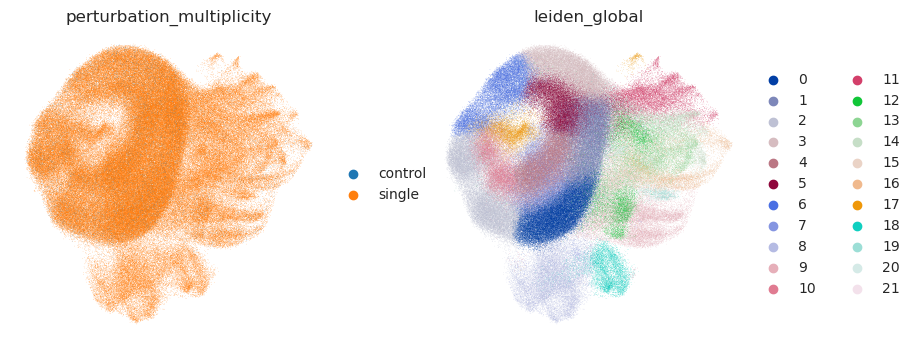

In [36]:
sc.pl.umap(ad, color=["perturbation_multiplicity", "leiden_global"], frameon=False)

In [40]:
ad.obs["analysis_group"].cat.categories

Index(['control', 'single'], dtype='object')

In [42]:
group_dir = f"{outdir}/groups"
os.makedirs(group_dir, exist_ok=True)

for group in ad.obs["analysis_group"].cat.categories:
    sub = ad[ad.obs["analysis_group"] == group].copy()
    
    print(f"\nProcessing group: {group}")
    print(sub)
    
    if sub.n_obs < 500:
        print(f"Skipping {group}: too few cells.")
        continue
    
    # Recalculate HVGs within this group.
    # Use seurat here because sub.X is already log-normalized.
    sc.pp.highly_variable_genes(
        sub,
        n_top_genes=min(3000, sub.n_vars),
        flavor="seurat"
    )
    
    sub_hvg = sub[:, sub.var["highly_variable"]].copy()
    
    n_comps = min(50, sub_hvg.n_obs - 1, sub_hvg.n_vars - 1)
    
    sc.pp.pca(
        sub_hvg,
        n_comps=n_comps,
        use_highly_variable=False,
        svd_solver="arpack"
    )
    
    sub.obsm["X_pca"] = sub_hvg.obsm["X_pca"]
    
    sc.pp.neighbors(
        sub,
        use_rep="X_pca",
        n_neighbors=30,
        n_pcs=n_comps,
        key_added="neighbors_within_group"
    )
    
    sc.tl.leiden(
        sub,
        resolution=1.0,
        neighbors_key="neighbors_within_group",
        key_added="leiden_within_group"
    )
    
    sc.tl.umap(
        sub,
        neighbors_key="neighbors_within_group"
    )
    
    out_path = f"{group_dir}/Replogle_K562_essential_{group}_processed.h5ad"
    sub.write(out_path)
    
    print(f"Saved group object to:\n{out_path}")


Processing group: control
AnnData object with n_obs × n_vars = 10691 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'condition', 'perturbation_multiplicity', 'analysis_group', 'leiden_global'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'leiden_global', 'log1p', 'neighbors_global', 'umap', 'condition_colors', 'leiden_global_colors', 'gene_colors', 'gene_id_colors', 'transcript_colors', 'gene_transcript_colors', 'guide_id_colors', 'disease_colors', 'cancer_colors', 'cell_line_colors', 'sex_colors', 'perturba

/ibex/user/chenj0i/conda/envs/seacells/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/tmp/ipykernel_1450211/3001142473.py:43: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Saved group object to:
/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential/groups/Replogle_K562_essential_control_processed.h5ad

Processing group: single
AnnData object with n_obs × n_vars = 299694 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'condition', 'perturbation_multiplicity', 'analysis_group', 'leiden_global'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'leiden_global', 'log1p', 'neighbors_global', 'umap', 'condition_colors', 'leiden_global_colors', 'gene_colors', 'gene_id_

/ibex/user/chenj0i/conda/envs/seacells/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Saved group object to:
/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential/groups/Replogle_K562_essential_single_processed.h5ad


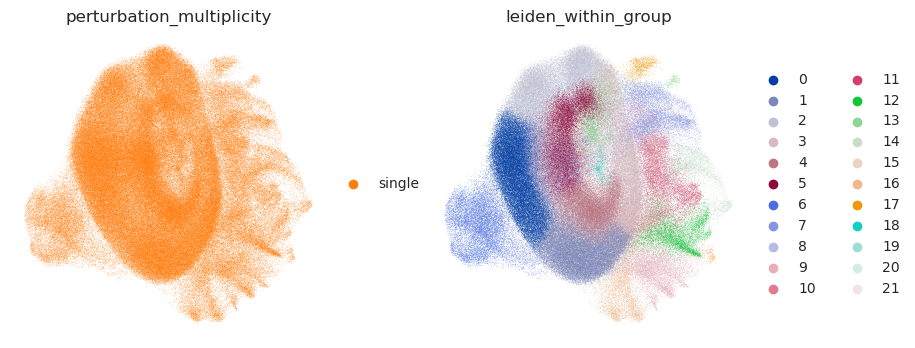

In [48]:
sc.pl.umap(sub, color=["perturbation_multiplicity", "leiden_within_group"], frameon=False)

In [46]:
sub

AnnData object with n_obs × n_vars = 299694 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'condition', 'perturbation_multiplicity', 'analysis_group', 'leiden_global', 'leiden_within_group'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_global', 'log1p', 'neighbors_global', 'umap', 'condition_colors', 'leiden_global_colors', 'gene_colors', 'gene_id_colors', 'transcript_colors', 'gene_transcript_colors', 'guide_id_colors', 'disease_colors', 'cancer_colors', 'cell_line_

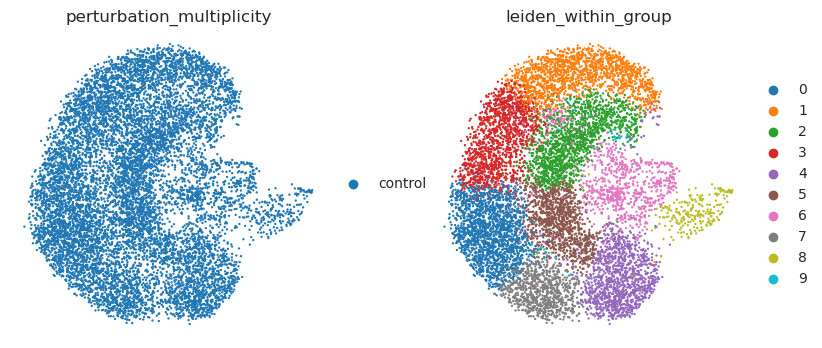

In [47]:
sub_ctrl = sc.read("/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential/groups/Replogle_K562_essential_control_processed.h5ad")
sc.pl.umap(sub_ctrl, color=["perturbation_multiplicity", "leiden_within_group"], frameon=False)

### Metacell processing on Replogle K562
Load separated cell groups and conduct SEACells to handle metacell generation

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import os

import SEACells

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100

sub_ctrl = sc.read("/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential/groups/Replogle_K562_essential_control_processed.h5ad")
sub_pert = sc.read("/ibex/user/chenj0i/Perturbation/data/processed_data/Replogle_K562_essential/groups/Replogle_K562_essential_single_processed.h5ad")

In [7]:
sub_ctrl

AnnData object with n_obs × n_vars = 10691 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'condition', 'perturbation_multiplicity', 'analysis_group', 'leiden_global', 'leiden_within_group'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'analysis_group_colors', 'cancer_colors', 'cell_line_colors', 'condition_colors', 'disease_colors', 'gene_colors', 'gene_id_colors', 'gene_transcript_colors', 'guide_id_colors', 'hvg', 'leiden_global', 'leiden_global_colors', 'leiden_within_group', 'l

In [8]:
sub_pert

AnnData object with n_obs × n_vars = 299694 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'condition', 'perturbation_multiplicity', 'analysis_group', 'leiden_global', 'leiden_within_group'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'analysis_group_colors', 'cancer_colors', 'cell_line_colors', 'condition_colors', 'disease_colors', 'gene_colors', 'gene_id_colors', 'gene_transcript_colors', 'guide_id_colors', 'hvg', 'leiden_global', 'leiden_global_colors', 'leiden_within_group', '

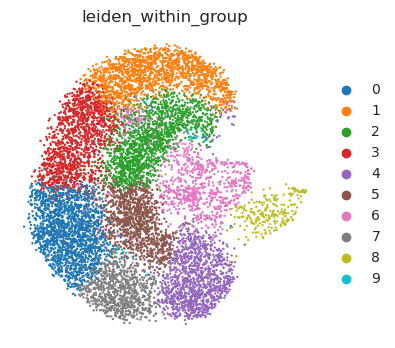

In [3]:
sc.pl.umap(sub_ctrl, color=["leiden_within_group"], frameon=False)

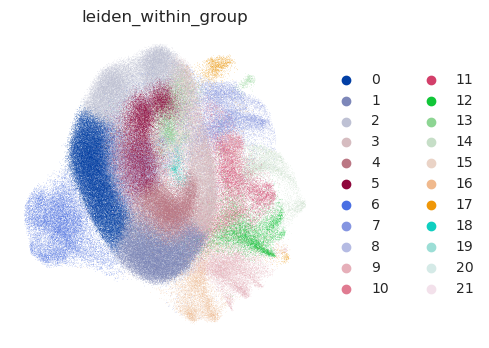

In [4]:
sc.pl.umap(sub_pert, color=["leiden_within_group"], frameon=False)

### SEACells parameter define

Welcome to SEACells!
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/10691 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/10691 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/10691 [00:00<?, ?it/s]

Constructing CSR matrix...
Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 327 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 33/33 [00:00<00:00, 69.52it/s]


Selecting 23 cells from greedy initialization.


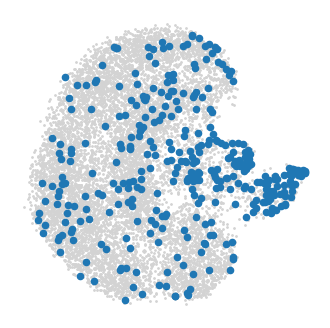

In [ ]:
# ## Core parameters 
# n_SEACells = 350
# build_kernel_on = 'X_pca' # key in ad.obsm to use for computing metacells
#                           # This would be replaced by 'X_svd' for ATAC data

# ## Additional parameters
# n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells

# model = SEACells.core.SEACells(sub_ctrl, 
#                   build_kernel_on=build_kernel_on, 
#                   n_SEACells=n_SEACells, 
#                   n_waypoint_eigs=n_waypoint_eigs,
#                   convergence_epsilon = 1e-5)

# model.construct_kernel_matrix()
# M = model.kernel_matrix

# # Initialize archetypes
# model.initialize_archetypes()

# # Plot the initilization to ensure they are spread across phenotypic space
# SEACells.plot.plot_initialization(sub_ctrl, model)

In [ ]:
# model.fit(min_iter=10, max_iter=90)

Randomly initialized A matrix.
Setting convergence threshold at 0.00185
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Starting iteration 30.
Completed iteration 30.
Starting iteration 40.
Completed iteration 40.
Converged after 49 iterations.


Ran for 50 iterations
Ran for 55 iterations


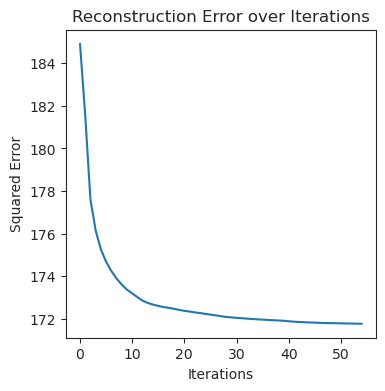

In [ ]:
# # You can force the model to run additional iterations step-wise using the .step() function
# print(f'Ran for {len(model.RSS_iters)} iterations')
# for _ in range(5):
#     model.step()
# print(f'Ran for {len(model.RSS_iters)} iterations')

# # Check for convergence 
# model.plot_convergence()

In [ ]:
# raw_ad = sc.AnnData(sub_ctrl.X)
# raw_ad.obs_names, raw_ad.var_names = sub_ctrl.obs_names, sub_ctrl.var_names
# sub_ctrl.raw = raw_ad

In [ ]:
# SEACell_ctrl_meta_hard = SEACells.core.summarize_by_SEACell(sub_ctrl, SEACells_label='SEACell', summarize_layer='raw')
# SEACell_ctrl_meta_hard

100%|██████████| 350/350 [00:02<00:00, 139.18it/s]
/ibex/user/chenj0i/conda/envs/seacells/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 350 × 8563
    layers: 'raw'

In [ ]:
# SEACells.plot.plot_2D(sub_ctrl, key='X_umap', colour_metacells=True)